# Building Age Classification from Satellite Imagery

# Notebook 3 — Feature Engineering & Preprocessing

---

This notebook transforms the raw wide-format Landsat parquet files into per-pixel feature vectors
suitable for machine learning.

**City roles**

| City | Role |
|------|------|
| **Madrid** | Labelled training city — used for cross-validation and model training in Notebook 4 |
| **Amsterdam** | Transfer target — a few labelled examples are used for few-shot adaptation in Notebook 4 |

**Key design choice: one row per pixel, not per observation**

The raw data contains one row per *(pixel, year)* pair — a pixel observed for 40 years contributes 40 rows.
Feeding raw per-year rows to a classifier treats each year as an independent sample and leaks
temporal structure. Instead we collapse each pixel's full time series into a single feature vector
of temporal statistics. This forces the model to reason about *trends and variability over time*,
which is exactly what distinguishes age classes.

** NOTE**:  these are only **suggestions** for feature processing. iIn your own code, you may decide to use different features.  "The proof of the puddign is in the eating"--in the end it is the _predictive performance_ that determines whether or not a feature set is good.

## 3.1 Setup & Imports

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ── Constants ─────────────────────────────────────────────────────────────────
BASE_BANDS   = ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
INDEX_COLS   = ['NDVI', 'NDBI', 'UI', 'MNDWI', 'BSI']
BLUE_MAX     = 15_000   # atmospheric outlier threshold — see Notebook 2

CLASS_EVENTS = {'Amsterdam': 1945, 'Madrid': 1960}
CLASS_COLORS = {1: '#4393c3', 2: '#2ca25f', 3: '#fd8d3c', 4: '#de2d26'}
CLASS_LABELS = {
    'Amsterdam': {1: 'Pre-1945',  2: '1945-1984', 3: '1984-2004', 4: '2004-2024'},
    'Madrid':    {1: 'Pre-1960',  2: '1960-1984', 3: '1984-2004', 4: '2004-2024'},
}

plt.rcParams['figure.dpi'] = 100
print("Setup complete.")


Setup complete.


---

## 3.2 Load the Data

Each file is one city's complete time series in wide format: one row per *(pixel, year)*,
with up to three Landsat observations stored side-by-side as `Blue_1 / Blue_2 / Blue_3`, etc.
The `qa_valid_N` flags indicate which observations passed the cloud/shadow quality filter.

In [12]:
DATA_DIR = '../data'

df_madrid    = pd.read_parquet(f'{DATA_DIR}/madrid_train.parquet')
df_amsterdam = pd.read_parquet(f'{DATA_DIR}/amsterdam_data.parquet')

for name, df in [('Madrid', df_madrid), ('Amsterdam', df_amsterdam)]:
    print(f'{name}: {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'  Years:  {df["year"].min()}-{df["year"].max()}  ({df["year"].nunique()} distinct years)')
    print(f'  Pixels: {df.groupby(["px_key","py_key"]).ngroups:,} unique geographic pixels')
    print()


Madrid: 3,172,765 rows x 48 columns
  Years:  1984-2025  (42 distinct years)
  Pixels: 76,263 unique geographic pixels

Amsterdam: 1,062,877 rows x 48 columns
  Years:  1984-2025  (42 distinct years)
  Pixels: 25,992 unique geographic pixels



---

## 3.3 Assign Age Classes

`weighted_mean_year` is the BAG-weighted estimated construction year for each pixel.
We cut it into four ordered age classes using city-specific boundaries identified in Notebook 1.

| Class | Madrid | Amsterdam |
|-------|--------|-----------|
| 1 | Pre-1960 | Pre-1945 |
| 2 | 1960-1984 | 1945-1984 |
| 3 | 1984-2004 | 1984-2004 |
| 4 | 2004-2024 | 2004-2024 |

Classes 3 and 4 fall entirely within the Landsat observation record (1984-present),
so the spectral signature around the construction year may be directly visible in the time series.

In [13]:
def assign_age_class(data, events=CLASS_EVENTS):
    out = data.copy()
    out['age_class'] = pd.NA
    for city, ev in events.items():
        mask = out['city'] == city
        if mask.any():
            bins = [-np.inf, ev, 1984, 2004, np.inf]
            out.loc[mask, 'age_class'] = pd.cut(
                out.loc[mask, 'weighted_mean_year'],
                bins=bins, labels=[1, 2, 3, 4]
            ).astype('Int64')
    return out

df_madrid    = assign_age_class(df_madrid)
df_amsterdam = assign_age_class(df_amsterdam)

for name, df in [('Madrid', df_madrid), ('Amsterdam', df_amsterdam)]:
    labels = CLASS_LABELS[name]
    pixels = df.drop_duplicates(['px_key', 'py_key'])
    print(f'{name} ({pixels["age_class"].notna().sum():,} labelled pixels):')
    for cls in [1, 2, 3, 4]:
        n = (pixels['age_class'] == cls).sum()
        print(f'  Class {cls} ({labels[int(cls)]}): {n:,}')
    print()


Madrid (76,263 labelled pixels):
  Class 1 (Pre-1960): 13,794
  Class 2 (1960-1984): 27,152
  Class 3 (1984-2004): 18,672
  Class 4 (2004-2024): 16,645

Amsterdam (25,992 labelled pixels):
  Class 1 (Pre-1945): 7,568
  Class 2 (1945-1984): 8,802
  Class 3 (1984-2004): 6,745
  Class 4 (2004-2024): 2,877



---

## 3.4 Flatten to One Best Observation Per Year

Each row currently stores up to three observations sorted by day-of-year.
`make_flat_view()` picks the first QA-valid observation for each band, then discards rows
where no valid observation exists for any band.

**Atmospheric outlier removal:** Landsat 7 scenes in Amsterdam contain haze not caught
by the standard QA flags. Blue reflectance > 15,000 reliably identifies these contaminated
observations (normal urban Blue peaks around 10,000). These rows are removed before
any feature computation.

In [14]:
def get_best_obs_band(data, band):
    col = np.full(len(data), np.nan)
    for slot in [1, 2, 3]:
        bc = f'{band}_{slot}'
        qc = f'qa_valid_{slot}'
        if bc not in data.columns or qc not in data.columns:
            continue
        valid = data[qc].fillna(False).values
        col = np.where(np.isnan(col) & valid, data[bc].fillna(np.nan).values, col)
    return col

def make_flat_view(data):
    keep = [c for c in ['pixel_id', 'city', 'year', 'px_key', 'py_key',
                        'weighted_mean_year', 'age_class']
            if c in data.columns]
    out = data[keep].copy()
    for band in BASE_BANDS:
        out[band] = get_best_obs_band(data, band)
    out = out.dropna(subset=BASE_BANDS)
    n_before = len(out)
    out = out[out['Blue'] <= BLUE_MAX].copy()
    removed = n_before - len(out)
    if removed:
        city = data['city'].iloc[0] if 'city' in data.columns else ''
        print(f'  [{city}] Removed {removed:,} haze-contaminated rows (Blue > {BLUE_MAX:,})')
    return out

print('Flattening observations...')
flat_madrid    = make_flat_view(df_madrid)
flat_amsterdam = make_flat_view(df_amsterdam)

for name, flat in [('Madrid', flat_madrid), ('Amsterdam', flat_amsterdam)]:
    n_pix = flat.groupby(['px_key', 'py_key']).ngroups
    print(f'{name}: {len(flat):,} valid pixel-year rows, {n_pix:,} unique pixels')

# ── Period coverage indicators ─────────────────────────────────────────────────
# Computed NOW, before gap-filling, while the original observed-year pattern is intact.
EARLY_CUTOFF = 2003   # 1984-2003: first ~20 years of Landsat record
LATE_START   = 2004   # 2004+:     most recent ~20 years
PID          = ['px_key', 'py_key']

def period_coverage(flat):
    pixels    = flat[PID].drop_duplicates()
    has_early = flat[flat['year'] <= EARLY_CUTOFF].drop_duplicates(PID).assign(has_early_data=1.0)
    has_late  = flat[flat['year'] >= LATE_START].drop_duplicates(PID).assign(has_late_data=1.0)
    ind = (pixels
           .merge(has_early[PID + ['has_early_data']], on=PID, how='left')
           .merge(has_late[PID  + ['has_late_data']],  on=PID, how='left')
           .fillna(0.0))
    return ind

indicators_madrid    = period_coverage(flat_madrid)
indicators_amsterdam = period_coverage(flat_amsterdam)

for name, ind in [('Madrid', indicators_madrid), ('Amsterdam', indicators_amsterdam)]:
    print(f'{name}: {(ind["has_early_data"]==0).sum()} pixels with no early data, '
          f'{(ind["has_late_data"]==0).sum()} with no late data')


Flattening observations...
  [Madrid] Removed 34,845 haze-contaminated rows (Blue > 15,000)
  [Amsterdam] Removed 12,917 haze-contaminated rows (Blue > 15,000)
Madrid: 3,137,920 valid pixel-year rows, 76,263 unique pixels
Amsterdam: 1,049,960 valid pixel-year rows, 25,992 unique pixels
Madrid: 0 pixels with no early data, 163 with no late data
Amsterdam: 0 pixels with no early data, 7 with no late data


---

## 3.5 Time-Series Gap Filling

The observed flat data is sparse: each pixel has one row per year for which a cloud-free
Landsat scene was available — typically 30-40 of the 41 possible years. It does not cover
every year uniformly, and individual years are sometimes missing due to cloud cover or
scene selection.

We extend each pixel to a complete annual time series (one row per year from the first
to the last available year across all pixels):

- **Interior gaps** — years between two observed years: **linear interpolation**.
- **Before first observation**: backward-fill with the first observed value.
- **After last observation**: forward-fill with the last observed value.

After gap-filling, every pixel has a value for every year. Early- and late-period statistics
computed in the next section are therefore always defined, and no imputation step is needed.

> **Note:** All pixels have Landsat observations both before and after 2004 — the satellite
> has been recording every location since 1984 regardless of what building currently stands
> there. A Class 4 pixel (current building constructed after 2004) does have pre-2004
> observations; they show whatever occupied that location previously — an older building
> that was demolished, vacant land, or a construction site. The  /
>  indicators flag the rare cases where a pixel has no valid scenes at all
> in a period (e.g., due to persistent cloud cover in that location).

In [15]:
def fill_time_series_gaps(flat):
    year_min = flat['year'].min()
    year_max = flat['year'].max()
    all_years = list(range(year_min, year_max + 1))

    # Build complete (pixel x year) grid, inheriting constant per-pixel metadata
    pixels = flat[PID + ['city', 'weighted_mean_year', 'age_class']].drop_duplicates(PID)
    grid   = pixels.assign(_k=1).merge(
        pd.DataFrame({'year': all_years, '_k': 1}), on='_k'
    ).drop('_k', axis=1)

    # Merge in observed band values (NaN where year not observed)
    merged = grid.merge(flat[PID + ['year'] + BASE_BANDS], on=PID + ['year'], how='left')
    merged = merged.sort_values(PID + ['year'])

    def interp(s):
        s = s.interpolate(method='linear')   # interior gaps: linear
        return s.bfill().ffill()             # edges: nearest observed value

    for band in BASE_BANDS:
        merged[band] = merged.groupby(PID)[band].transform(interp)

    return merged

print('Filling time-series gaps...')
flat_madrid    = fill_time_series_gaps(flat_madrid)
flat_amsterdam = fill_time_series_gaps(flat_amsterdam)

for name, flat in [('Madrid', flat_madrid), ('Amsterdam', flat_amsterdam)]:
    n_pix = flat.groupby(PID).ngroups
    print(f'{name}: {len(flat):,} rows after gap-fill '
          f'({flat["year"].nunique()} years x {n_pix:,} pixels)')


Filling time-series gaps...
Madrid: 3,203,046 rows after gap-fill (42 years x 76,263 pixels)
Amsterdam: 1,091,664 rows after gap-fill (42 years x 25,992 pixels)


---

## 3.5 Spectral Indices

Normalised band ratios are less sensitive to illumination differences between scenes and
sensors, and highlight specific surface properties.

| Index | Formula | What it captures |
|-------|---------|-----------------|
| NDVI | (NIR - Red) / (NIR + Red) | Vegetation — low values indicate built-up surfaces |
| NDBI | (SWIR1 - NIR) / (SWIR1 + NIR) | Built-up intensity |
| UI | (SWIR2 - NIR) / (SWIR2 + NIR) | Urban areas |
| MNDWI | (Green - SWIR1) / (Green + SWIR1) | Water; negative for built-up land |
| BSI | ((SWIR1+Red)-(NIR+Blue)) / ((SWIR1+Red)+(NIR+Blue)) | Bare soil vs vegetated |

These are computed per observation (per pixel-year row) and then aggregated into temporal
statistics in the next section.

In [16]:
def compute_spectral_indices(df):
    df = df.copy()
    B, G, R = df['Blue'], df['Green'], df['Red']
    N, S1, S2 = df['NIR'], df['SWIR1'], df['SWIR2']
    eps = 1e-6
    df['NDVI']  = (N - R)  / (N + R  + eps)
    df['NDBI']  = (S1 - N) / (S1 + N + eps)
    df['UI']    = (S2 - N) / (S2 + N + eps)
    df['MNDWI'] = (G - S1) / (G + S1 + eps)
    df['BSI']   = ((S1 + R) - (N + B)) / ((S1 + R) + (N + B) + eps)
    return df

flat_madrid    = compute_spectral_indices(flat_madrid)
flat_amsterdam = compute_spectral_indices(flat_amsterdam)

print('Spectral indices added.')
flat_madrid[INDEX_COLS].describe().round(4)


Spectral indices added.


,NDVI,NDBI,UI,MNDWI,BSI
count,3.203046e+06,3.203046e+06,3.203046e+06,3.203046e+06,3.203046e+06
mean,9.550000e-02,2.080000e-02,-2.430000e-02,-1.616000e-01,4.920000e-02
std,5.690000e-02,5.370000e-02,7.130000e-02,5.370000e-02,3.950000e-02
min,-4.666000e-01,-6.765000e-01,-7.082000e-01,-1.000000e+00,-5.268000e-01
25%,5.530000e-02,-1.170000e-02,-6.550000e-02,-1.992000e-01,2.560000e-02
50%,8.180000e-02,2.440000e-02,-1.860000e-02,-1.606000e-01,5.140000e-02
75%,1.232000e-01,5.780000e-02,2.450000e-02,-1.247000e-01,7.630000e-02
max,8.634000e-01,6.355000e-01,6.378000e-01,3.191000e-01,5.543000e-01


---

## 3.6 Per-Pixel Temporal Feature Engineering

This is the most important section. Each pixel's time series — up to 40 annual observations —
is collapsed into a fixed-length feature vector. The goal is to capture *how the spectral
signature changes over time*, not just what it looks like at a single moment.

### Feature groups

| Group | Features | Count |
|-------|----------|-------|
| Overall mean per band |  | 6 |
| Overall std per band |  | 6 |
| Overall mean per spectral index |  | 5 |
| Overall std per spectral index |  | 5 |
| Early-period mean (1984-2003) |  | 6 |
| Early-period std (1984-2003) |  | 6 |
| Late-period mean (2004+) |  | 6 |
| Late-period std (2004+) |  | 6 |
| Year-on-year change mean |  | 6 |
| Year-on-year change std |  | 6 |
| Period coverage indicator | `has_early_data`, `has_late_data` | 2 |
| **Total** | | **60** |

**Why split at 2004?** The 1984-2003 window shows the *pre-existing* land use at each
location, while 2004+ shows the *current* building's spectral signature. For Classes 1
and 2 (pre-1984 buildings) the split falls entirely within the building's lifetime, so
both periods reflect the same structure and the signals should be stable. For Class 3
(built 1984-2004) the construction event falls somewhere in the early period, and for
Class 4 (built after 2004) the early period captures what was demolished or replaced —
an older building, a field, or a construction site. The contrast between early and late
statistics should therefore be largest and most class-discriminative for Classes 3 and 4.

**Why year-on-year change?** As seen in Notebook 2, the std of annual change separates
pre-satellite-era buildings (Classes 1 & 2, narrow YOY distribution) from those built during
the record (Classes 3 & 4, broader distribution). This is a direct time-series signal.

In [17]:
def build_pixel_features(flat):
    s = flat[flat['age_class'].notna()].copy()
    s = s.sort_values(PID + ['year'])

    # ── Overall stats: bands + indices ────────────────────────────────────────
    grp = s.groupby(PID + ['age_class'])
    overall = pd.concat([
        grp[BASE_BANDS + INDEX_COLS].mean().add_suffix('_mean'),
        grp[BASE_BANDS + INDEX_COLS].std().add_suffix('_std'),
    ], axis=1).reset_index()
    overall['age_class'] = overall['age_class'].astype(int)

    # ── Early-period stats (1984-2003) ────────────────────────────────────────
    early_grp = s[s['year'] <= EARLY_CUTOFF].groupby(PID)
    early = pd.concat([
        early_grp[BASE_BANDS].mean().add_suffix('_early_mean'),
        early_grp[BASE_BANDS].std().add_suffix('_early_std'),
    ], axis=1).reset_index()

    # ── Late-period stats (2004+) ─────────────────────────────────────────────
    late_grp = s[s['year'] >= LATE_START].groupby(PID)
    late = pd.concat([
        late_grp[BASE_BANDS].mean().add_suffix('_late_mean'),
        late_grp[BASE_BANDS].std().add_suffix('_late_std'),
    ], axis=1).reset_index()

    # ── Year-on-year change stats ─────────────────────────────────────────────
    for b in BASE_BANDS:
        s[f'd_{b}'] = s.groupby(PID)[b].diff()
    dcols = [f'd_{b}' for b in BASE_BANDS]
    diff_grp = s.groupby(PID)[dcols]
    diff = pd.concat([
        diff_grp.mean().add_suffix('_mean'),
        diff_grp.std().add_suffix('_std'),
    ], axis=1).reset_index()

    yr = s.groupby(PID)['weighted_mean_year'].first().reset_index()

    result = overall
    for extra in [early, late, diff, yr]:
        result = result.merge(extra, on=PID, how='left')
    return result

print('Building per-pixel feature vectors...')
features_madrid    = build_pixel_features(flat_madrid)
features_amsterdam = build_pixel_features(flat_amsterdam)

# ── Merge period indicators ───────────────────────────────────────────────────
features_madrid    = features_madrid.merge(indicators_madrid,    on=PID, how='left')
features_amsterdam = features_amsterdam.merge(indicators_amsterdam, on=PID, how='left')

for name, feat in [('Madrid', features_madrid), ('Amsterdam', features_amsterdam)]:
    print(f'{name}: {len(feat):,} pixels, {feat.shape[1]} total columns')
    print(f'  has_early_data=0: {(feat["has_early_data"]==0).sum()} pixels  '
          f'(gap-filled early period)')

# ── Feature column lists ──────────────────────────────────────────────────────
FEAT_OVERALL = [f'{b}_mean' for b in BASE_BANDS] + [f'{b}_std' for b in BASE_BANDS]
FEAT_INDICES = [f'{i}_mean' for i in INDEX_COLS] + [f'{i}_std'  for i in INDEX_COLS]
FEAT_EARLY   = [f'{b}_early_mean' for b in BASE_BANDS] + [f'{b}_early_std' for b in BASE_BANDS]
FEAT_LATE    = [f'{b}_late_mean'  for b in BASE_BANDS] + [f'{b}_late_std'  for b in BASE_BANDS]
FEAT_YOY     = [f'd_{b}_mean' for b in BASE_BANDS] + [f'd_{b}_std' for b in BASE_BANDS]
FEAT_IND     = ['has_early_data', 'has_late_data']

FEATURE_COLS = FEAT_OVERALL + FEAT_INDICES + FEAT_EARLY + FEAT_LATE + FEAT_YOY + FEAT_IND
print(f'\nTotal features: {len(FEATURE_COLS)}  '
      f'(12 overall + 10 indices + 12 early + 12 late + 12 YOY + 2 indicators)')


Building per-pixel feature vectors...
Madrid: 76,263 pixels, 64 total columns
  has_early_data=0: 0 pixels  (gap-filled early period)
Amsterdam: 25,992 pixels, 64 total columns
  has_early_data=0: 0 pixels  (gap-filled early period)

Total features: 60  (12 overall + 10 indices + 12 early + 12 late + 12 YOY + 2 indicators)


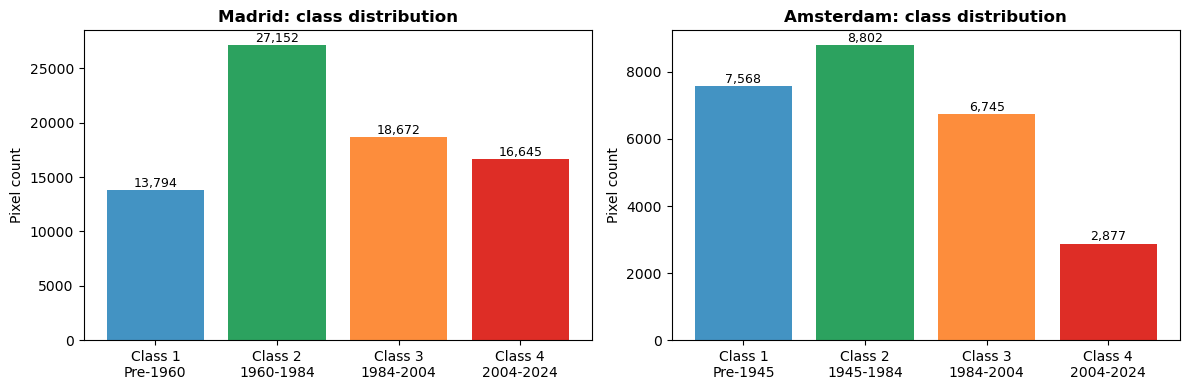

In [18]:
# ── Class distribution per city ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, feat) in zip(axes, [('Madrid', features_madrid),
                                    ('Amsterdam', features_amsterdam)]):
    labels = CLASS_LABELS[name]
    classes = [1, 2, 3, 4]
    counts  = [(feat['age_class'] == c).sum() for c in classes]
    xlbls   = [f'Class {c}\n{labels[c]}' for c in classes]
    bars    = ax.bar(xlbls, counts, color=[CLASS_COLORS[c] for c in classes], edgecolor='none')
    for bar, n in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                f'{n:,}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Pixel count')
    ax.set_title(f'{name}: class distribution', fontweight='bold')
plt.tight_layout()
plt.show()


---

## 3.7 Standardisation

After time-series gap filling, no NaN values remain in the feature matrix — every pixel
has a value for every year and therefore defined early-, late-, and YOY-period statistics.

`StandardScaler` normalises each feature to zero mean and unit variance. This matters
for the k-NN and prototype classifiers used in Notebook 4, where distances depend on
scale. It is fit on Madrid only and applied to Amsterdam, maintaining the correct protocol
for cross-city transfer.

In [19]:
TARGET_COL = 'age_class'

X_madrid    = features_madrid[FEATURE_COLS].values.astype(np.float64)
y_madrid    = features_madrid[TARGET_COL].values.astype(int)
X_amsterdam = features_amsterdam[FEATURE_COLS].values.astype(np.float64)
y_amsterdam = features_amsterdam[TARGET_COL].values.astype(int)

# Sanity check
for name, X in [('Madrid', X_madrid), ('Amsterdam', X_amsterdam)]:
    n_nan = np.isnan(X).any(axis=1).sum()
    status = 'OK' if n_nan == 0 else f'WARNING: {n_nan} pixels with NaN'
    print(f'{name}: {X.shape}  NaN check: {status}')

scaler = StandardScaler()
X_madrid    = scaler.fit_transform(X_madrid)
X_amsterdam = scaler.transform(X_amsterdam)
print('Standardised.')


Madrid: (76263, 60)  NaN check: OK
Amsterdam: (25992, 60)  NaN check: OK
Standardised.


---

## 3.8 Save Preprocessed Data

The preprocessed arrays are saved so Notebook 4 can load them directly without repeating
these steps.

In [20]:
import pickle
from pathlib import Path

output_dir = Path('../data/preprocessed')
output_dir.mkdir(exist_ok=True)

data = {
    'X_madrid':            X_madrid,
    'y_madrid':            y_madrid,
    'X_amsterdam':         X_amsterdam,
    'y_amsterdam':         y_amsterdam,
    'feature_names':       FEATURE_COLS,
    'scaler':              scaler,
    'pixel_ids_madrid':    features_madrid[['px_key', 'py_key']].values,
    'pixel_ids_amsterdam': features_amsterdam[['px_key', 'py_key']].values,
    'feat_groups': {
        'overall':    FEAT_OVERALL,
        'indices':    FEAT_INDICES,
        'early':      FEAT_EARLY,
        'late':       FEAT_LATE,
        'yoy':        FEAT_YOY,
        'indicators': FEAT_IND,
    },
}

save_path = output_dir / 'preprocessed_data.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(data, f)

size_mb = save_path.stat().st_size / 1024 / 1024
print(f'Saved to: {save_path}  ({size_mb:.1f} MB)')


Saved to: ..\data\preprocessed\preprocessed_data.pkl  (48.4 MB)


---

## 3.9 Summary

In this notebook we:

1. **Loaded** `madrid_train.parquet` (training city) and `amsterdam_data.parquet` (transfer target)
2. **Assigned age classes** from `weighted_mean_year` using city-specific boundaries
3. **Flattened** the wide-format data to one best QA-valid observation per pixel-year,
   removing haze-contaminated rows (Blue > 15,000)
4. **Recorded period coverage** — `has_early_data` and `has_late_data` binary indicators
   computed from the original observed years before any gap-filling
5. **Filled time-series gaps** by linear interpolation between observed years; edge values
   (before first obs / after last obs) are set to the nearest observed value
6. **Computed 5 spectral indices** (NDVI, NDBI, UI, MNDWI, BSI) on the gap-filled series
7. **Aggregated to one row per pixel** using temporal statistics (60 features total):
   - Overall mean/std for all bands and indices (22 features)
   - Early-period mean/std, 1984-2003 (12 features)
   - Late-period mean/std, 2004+ (12 features)
   - Year-on-year change mean/std (12 features)
   - Period coverage indicators (2 features)
8. **Standardised** using StandardScaler fit on Madrid only
9. **Saved** the preprocessed arrays for Notebook 4

**Next:** Open Notebook 4 to train and evaluate the classifier.